In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def read_xyz(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    n_atoms = int(lines[0])

    coords = []

    for line in lines[2:]:
        parts = line.split()

        x = float(parts[1])
        y = float(parts[2])
        z = float(parts[3])

        coords.append([x, y, z])

    return np.array(coords), n_atoms

In [ ]:
_, n_atoms = read_xyz("LJ_13.xyz")

sigma = 1.0;
epsilon = 1.0
k_b = 1.0

In [11]:
def lj_energy(positions):

    N = n_atoms

    energy = 0.0

    for i in range(N):
        for j in range(i+1, N):

            rij = positions[i] - positions[j]

            r = np.linalg.norm(rij)

            energy += 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

    return energy

In [12]:
def atom_energy(position, atom_index):
    
    N = n_atoms

    i = atom_index
    
    new_atom_energy = 0.0

    for j in range(N):
        
        if j == i:
            continue

        rij = position[i] - position[j]

        r = np.linalg.norm(rij)

        new_atom_energy += 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

    return new_atom_energy


In [13]:
def trial_move(positions, max_displacement):

    new_positions = positions.copy()

    atom = np.random.randint(n_atoms)

    displacement = np.random.uniform(-max_displacement, max_displacement, size=3)

    new_positions[atom] += displacement

    return new_positions, atom

In [ ]:
coords, _ = read_xyz("LJ_13.xyz")
current_total_energy = lj_energy(coords)

temperature = 0.10

n_steps = 100000000

accepted_moves = 0

energy_history = []

configs = []

for step in range(n_steps):

    new_coords, atom = trial_move(coords, 0.043)

    old_local_energy = atom_energy(coords, atom)

    new_local_energy = atom_energy(new_coords, atom)

    deltaE = new_local_energy - old_local_energy

    if deltaE <= 0:
        accept = True

    else:
        probability = np.exp(-deltaE / (k_b*temperature))

        accept = np.random.rand() < probability


    if accept:
        coords = new_coords
        current_total_energy += deltaE
        accepted_moves += 1

   # if step % 100 == 0:
    #   print(f"Step {step}, Energy: {current_total_energy}")
    
    energy_history.append(current_total_energy)

    if step > 20000 and step % 4000 == 0:
        configs.append(coords.copy())

#print(f"Total accepted moves: {accepted_moves} out of {n_steps}")
print(f"Acceptance percentage: {accepted_moves*100/n_steps:.2f}%")

Acceptance percentage: 49.94%


Text(0.5, 1.0, 'Convergence check (burn-in diagnostic)')

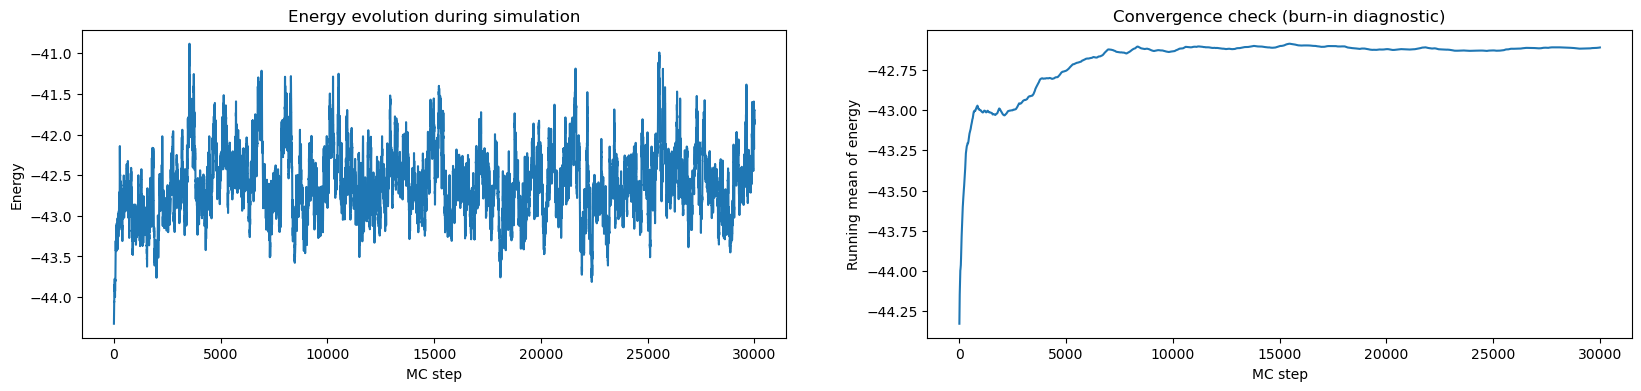

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(20, 4))
ax[0].plot(energy_history[:30000])
ax[0].set_xlabel("MC step")
ax[0].set_ylabel("Energy")
ax[0].set_title("Energy evolution during simulation")

running_mean = np.cumsum(energy_history) / np.arange(1, len(energy_history)+1)

ax[1].plot(running_mean[:30000])
ax[1].set_xlabel("MC step")
ax[1].set_ylabel("Running mean of energy")
ax[1].set_title("Convergence check (burn-in diagnostic)")

The energy and cumulative mean at each MC step shows that a burn-in of 20000 is reasonable

In [ ]:
def flyvbjerg_petersen(data):

    data = np.asarray(data, dtype=float).copy()

    block_sizes = []
    errors = []
    variances = []

    block_size = 1

    while len(data) >= 16:

        n = len(data)

        variance = np.var(data, ddof=1)

        error = np.sqrt(variance / n)

        block_sizes.append(block_size)
        errors.append(error)
        variances.append(variance)

        if n % 2 == 1:
            data = data[:-1]

        data = 0.5 * (data[0::2] + data[1::2])

        block_size *= 2

    return np.array(block_sizes), np.array(errors), np.array(variances)

In [36]:
production_energy = energy_history[20000:]

block_sizes, errors, variances = flyvbjerg_petersen(production_energy)

In [20]:
def autocorrelation(data, max_lag):

    data = np.asarray(data)

    data = data - np.mean(data)

    variance = np.var(data)

    autocorr = []

    for lag in range(max_lag):

        if lag == 0:
            numerator = np.mean(data * data)

        else:
            numerator = np.mean(
                data[:-lag] * data[lag:]
            )

        autocorr.append(numerator / variance)

    return np.array(autocorr)

In [21]:
autocorr = autocorrelation(production_energy, max_lag=5000)

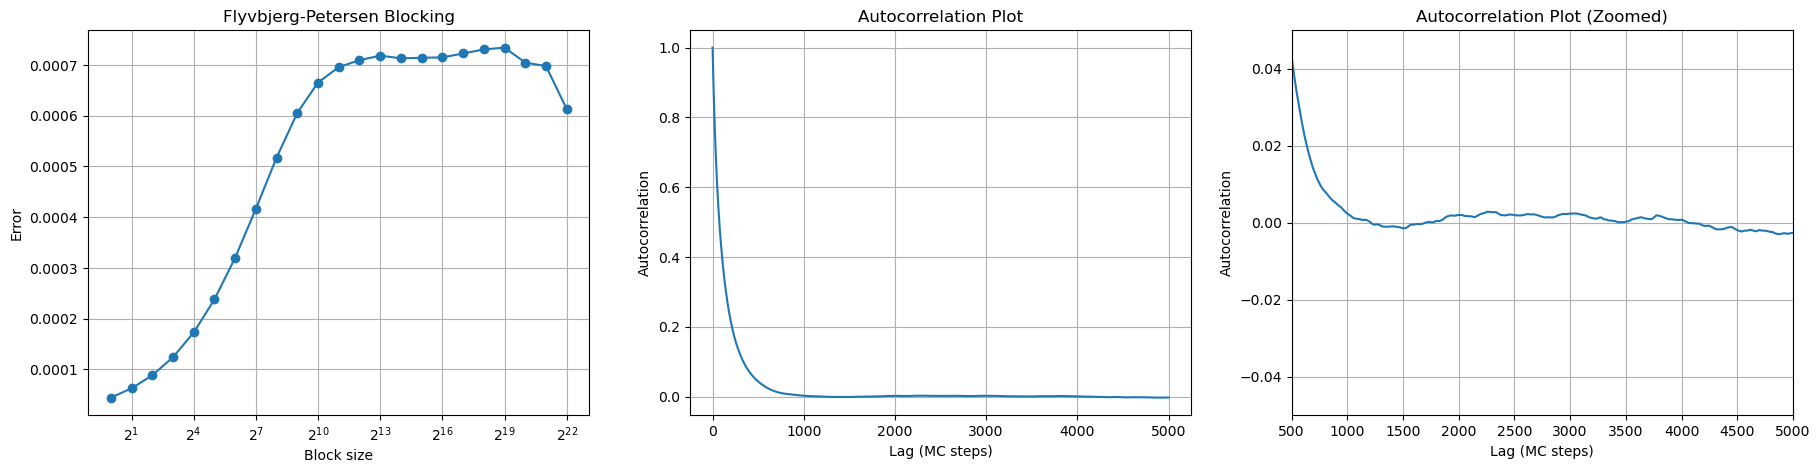

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(22, 5))

axs[0].plot(block_sizes, errors, marker='o')
axs[0].set_xscale('log', base=2)
axs[0].set_xlabel("Block size")
axs[0].set_ylabel("Error")
axs[0].grid(True)
axs[0].set_title('Flyvbjerg-Petersen Blocking')


axs[1].plot(range(5000),autocorr)
axs[1].set_xlabel("Lag (MC steps)")
axs[1].set_ylabel("Autocorrelation")
axs[1].grid(True)
axs[1].set_title('Autocorrelation Plot')

axs[2].plot(range(5000),autocorr)
axs[2].set_xlabel("Lag (MC steps)")
axs[2].set_ylabel("Autocorrelation")
axs[2].set_xlim([500, 5000])
axs[2].set_ylim([-0.05, 0.05])
axs[2].set_title('Autocorrelation Plot (Zoomed)')
axs[2].grid(True)


A block size of 4000 is where a "plateau" is apparent;
 
Autocorrelation vs lag plot shows the autocorrelation reaches a 0 plateau at a lag of areound 1000-2000

In [14]:
for b,e in zip(block_sizes, errors):
    print(b,e)

1 4.457773541543377e-05
2 6.285393659364234e-05
4 8.849471797487021e-05
8 0.00012415458849386572
16 0.00017295948396016552
32 0.00023786127860049247
64 0.0003201026477660072
128 0.00041655264623756573
256 0.0005174341685217614
512 0.0006054987181511668
1024 0.0006652017738936487
2048 0.0006955728581888555
4096 0.0007092112905347502
8192 0.0007181074046085755
16384 0.0007128350132331436
32768 0.0007139738768974555
65536 0.000714660106169573
131072 0.0007224086928485115
262144 0.0007303764556000321
524288 0.0007339380136360415
1048576 0.0007045043435399096
2097152 0.0006975147901412805
4194304 0.0006131613432824213


In [ ]:
np.save("LJ_13_configs.npy", configs)
np.save("LJ_13_energy.npy", energy_history)

In [15]:
energies = []

for config in configs:
    energies.append(lj_energy(config))

energies = np.array(energies)

In [ ]:
initial_coords, n_atoms = read_xyz("LJ13.xyz")

d = 3*n_atoms - 6

T = temperature

U_min = lj_energy(initial_coords)

U_mean = U_min + (d/2) * k_b * T

variance_theoretical = (d/2) * k_b * T**2

std_dev = np.sqrt(variance_theoretical)

U = np.linspace(-45, -40, 500)

P = (1/(np.sqrt(2*np.pi)*std_dev)*np.exp(-(U-U_mean)**2/(2*variance_theoretical)))

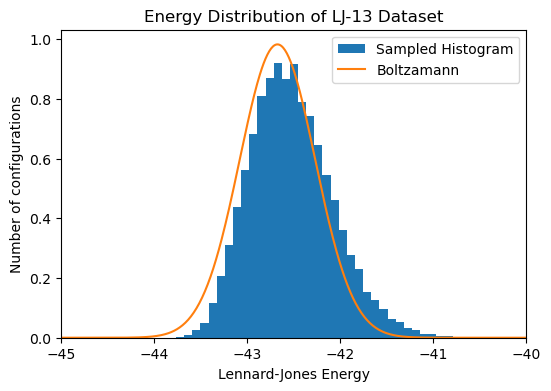

In [70]:
plt.figure(figsize=(6,4))
plt.hist(energies, bins=40, density=True, label='Sampled Histogram')
plt.plot(U,P, label='Boltzamann')

plt.xlabel("Lennard-Jones Energy")
plt.ylabel("Number of configurations")
plt.title("Energy Distribution of LJ-13 Dataset")
plt.xlim(-45, -40)
plt.legend()
plt.show()


A comparison with the Boltzmann distribution for the given temperature (T=0.1) is shown. A slight deviation can be observed which is probably due to the anharmonicity in LJ potential

In [17]:
print("Minimum energy :", np.min(energies))
print("Maximum energy :", np.max(energies))
print("Mean energy    :", np.mean(energies))
print("Std deviation  :", np.std(energies))

Minimum energy : -43.767628978524776
Maximum energy : -40.26786387692513
Mean energy    : -42.526261805569
Std deviation  : 0.4438247713605245


In [18]:
pair_distances = []

for config in configs:

    for i in range(n_atoms):

        for j in range(i+1, n_atoms):

            r = np.linalg.norm(config[i] - config[j])

            pair_distances.append(r)

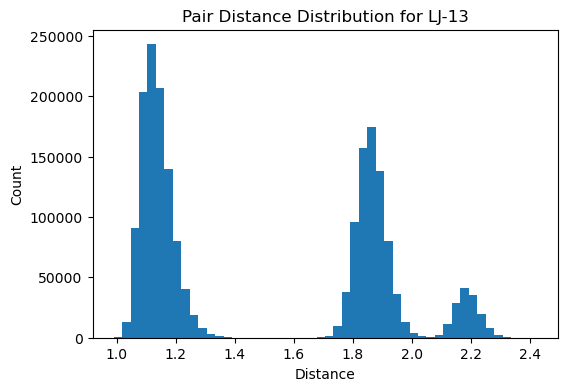

In [19]:
plt.figure(figsize=(6,4))

plt.hist(pair_distances, bins=50)

plt.xlabel("Distance")
plt.ylabel("Count")
plt.title("Pair Distance Distribution for LJ-13")

plt.show()

The pair distance / radial distrbution shows that there are three different distances between the atoms based on the relative positions of the atoms in the icosahedron

In [77]:
tau_int = 0.5

for c in autocorr[1:]:

    tau_int += c

print(tau_int)

Neff = n_steps/(2*tau_int)

print(Neff)
print(autocorr.shape)

134.06733601735507
372946.91969957156
(5000,)


Tau_int is found to be around 134. 

In [ ]:
energy_history = np.load("LJ_13_energy.npy")

tau_int = 134

N_total = len(energy_history)

N_values = np.logspace(2, np.log10(N_total), 100,dtype=int)

variance = []
std_dev = []
std_error = []


for N in N_values:

    data = energy_history[:N]
    
    N_eff = N / (2 * tau_int)
    
    var = np.var(data, ddof=1)
    std = np.sqrt(var)
    err = std / np.sqrt(N_eff)

    variance.append(var)
    std_dev.append(std)
    std_error.append(err)

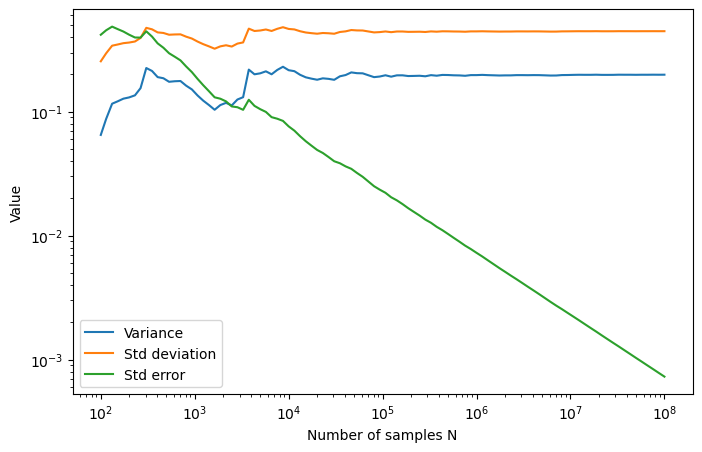

In [7]:
plt.figure(figsize=(8,5))

plt.plot(N_values, variance, label="Variance")
plt.plot(N_values, std_dev, label="Std deviation")
plt.plot(N_values, std_error, label="Std error")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of samples N")
plt.ylabel("Value")

plt.legend()
plt.show()

The variance, std deviation and std error were plotted as a function of the number of samples. As expected, the std deviation and the variance reach a plateau, whereas, the std error keeps decreasing as the number of samples increase. 